# MobileNetV3-Small Partial Unfreeze + Penalty Regularization

## Motivation
ResNet18 (11M params) overfits heavily on this dataset (~5k samples, 779 melanoma). MobileNetV3-Small has ~2.5M params and we further reduce active parameters by only unfreezing the last 3 blocks of the backbone, leaving the rest frozen.

## Architecture
MobileNetV3-Small `model.features` has 13 children:
- `[0]` stem conv
- `[1ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã…â€œ7]` MBConv blocks
- `[8]` head conv

`unfreeze_last_n_blocks=3` trains only the last 3 blocks + classifier.

## Lambda Sweep
| Run | l1_lambda | l2_lambda | Purpose |
|-----|-----------|-----------|--------|
| 0   | 0         | 0         | Baseline (no penalty) |
| 1   | 0         | 1e-4      | Mild L2 |
| 2   | 0         | 1e-3      | Moderate L2 |
| 3   | 1e-4      | 0         | Mild L1 |
| 4   | 1e-3      | 0         | Moderate L1 |

In [1]:
import sys
import os
from pathlib import Path

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import fbeta_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from src.data.dataloader import get_dataloaders
from src.models.mobilenet import get_mobilenet_v3_small
from src.training.trainer import train_one_epoch, validate_one_epoch

os.chdir(ROOT)
print(Path.cwd())

c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.mps.manual_seed(seed)

set_seed(42)

In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='data_new/splits/train.csv',
    val_csv='data_new/splits/val.csv',
    test_csv='data_new/splits/test.csv',
    image_dir='data_new/images/train',
    test_image_dir='data_new/images/test',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv('data_new/splits/train.csv')

num_melanoma = (train_df['label'] == 1).sum()   # melanoma in CSV (label=1)
num_nevus = (train_df['label'] == 0).sum()      # nevus in CSV (label=0)

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


## Lambda Sweep

In [5]:
all_results = {}

In [6]:
# --- Baseline (no penalty) ---
num_epochs = 20
run_label = 'Baseline'
l1_lambda = 0.0
l2_lambda = 0.0

print(f'=== Run: {run_label} (l1={l1_lambda}, l2={l2_lambda}) ===')
set_seed(42)

model = get_mobilenet_v3_small(num_classes=1, unfreeze_last_n_blocks=3).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5, min_lr=1e-6)

history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
best_val_f2 = 0.0
best_state = None

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f2'].append(train_metrics['f2'])
    history['val_f2'].append(val_metrics['f2'])

    scheduler.step(val_metrics['f2'])
    current_lr = optimizer.param_groups[0]['lr']

    print(f"  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    -> New best val F2: {best_val_f2:.4f}')

all_results[run_label] = {'history': history, 'best_val_f2': best_val_f2, 'best_state': best_state}
print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')

=== Run: Baseline (l1=0.0, l2=0.0) ===


  Epoch [1/20] | Train Loss: 1.0065, F2: 0.5117 | Val Loss: 0.8872, F2: 0.5603 | LR: 1.00e-04
    -> New best val F2: 0.5603


  Epoch [2/20] | Train Loss: 0.8028, F2: 0.5872 | Val Loss: 0.8168, F2: 0.6141 | LR: 1.00e-04
    -> New best val F2: 0.6141


  Epoch [3/20] | Train Loss: 0.7033, F2: 0.6327 | Val Loss: 0.7946, F2: 0.6196 | LR: 1.00e-04
    -> New best val F2: 0.6196


  Epoch [4/20] | Train Loss: 0.6604, F2: 0.6595 | Val Loss: 0.8213, F2: 0.6262 | LR: 1.00e-04
    -> New best val F2: 0.6262


...

  Epoch [16/20] | Train Loss: 0.2593, F2: 0.8699 | Val Loss: 1.1685, F2: 0.6398 | LR: 5.00e-05


  Epoch [17/20] | Train Loss: 0.2481, F2: 0.8756 | Val Loss: 1.2114, F2: 0.6240 | LR: 5.00e-05


  Epoch [18/20] | Train Loss: 0.2438, F2: 0.8839 | Val Loss: 1.2317, F2: 0.6264 | LR: 5.00e-05


  Epoch [19/20] | Train Loss: 0.2440, F2: 0.8745 | Val Loss: 1.2190, F2: 0.6259 | LR: 2.50e-05


  Epoch [20/20] | Train Loss: 0.2301, F2: 0.8839 | Val Loss: 1.2466, F2: 0.6150 | LR: 2.50e-05
Best val F2 for Baseline: 0.6402


In [7]:
# --- L2=1e-3 ---
num_epochs = 20
run_label = 'L2=1e-3'
l1_lambda = 0.0
l2_lambda = 1e-3

print(f'=== Run: {run_label} (l1={l1_lambda}, l2={l2_lambda}) ===')
set_seed(42)

model = get_mobilenet_v3_small(num_classes=1, unfreeze_last_n_blocks=3).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5, min_lr=1e-6)

history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
best_val_f2 = 0.0
best_state = None

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f2'].append(train_metrics['f2'])
    history['val_f2'].append(val_metrics['f2'])

    scheduler.step(val_metrics['f2'])
    current_lr = optimizer.param_groups[0]['lr']

    print(f"  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    -> New best val F2: {best_val_f2:.4f}')

all_results[run_label] = {'history': history, 'best_val_f2': best_val_f2, 'best_state': best_state}
print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')

=== Run: L2=1e-3 (l1=0.0, l2=0.001) ===


Train:   0%|          | 0/250 [00:00<?, ?it/s]

  Epoch [1/20] | Train Loss: 1.0106, F2: 0.5103 | Val Loss: 0.8918, F2: 0.5532 | LR: 1.00e-04
    -> New best val F2: 0.5532


  Epoch [2/20] | Train Loss: 0.8068, F2: 0.5860 | Val Loss: 0.8177, F2: 0.6148 | LR: 1.00e-04
    -> New best val F2: 0.6148


  Epoch [3/20] | Train Loss: 0.7060, F2: 0.6349 | Val Loss: 0.7857, F2: 0.6254 | LR: 1.00e-04
    -> New best val F2: 0.6254


...

  Epoch [16/20] | Train Loss: 0.2808, F2: 0.8620 | Val Loss: 1.0507, F2: 0.6471 | LR: 5.00e-05
    -> New best val F2: 0.6471


  Epoch [17/20] | Train Loss: 0.2781, F2: 0.8556 | Val Loss: 1.1179, F2: 0.6222 | LR: 5.00e-05


  Epoch [18/20] | Train Loss: 0.2609, F2: 0.8757 | Val Loss: 1.1576, F2: 0.6232 | LR: 5.00e-05


  Epoch [19/20] | Train Loss: 0.2762, F2: 0.8548 | Val Loss: 1.1340, F2: 0.6496 | LR: 5.00e-05
    -> New best val F2: 0.6496


  Epoch [20/20] | Train Loss: 0.2526, F2: 0.8727 | Val Loss: 1.1950, F2: 0.6334 | LR: 5.00e-05
Best val F2 for L2=1e-3: 0.6496


In [8]:
# --- L1=1e-3 ---
num_epochs = 20
run_label = 'L1=1e-3'
l1_lambda = 1e-3
l2_lambda = 0.0

print(f'=== Run: {run_label} (l1={l1_lambda}, l2={l2_lambda}) ===')
set_seed(42)

model = get_mobilenet_v3_small(num_classes=1, unfreeze_last_n_blocks=3).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5, min_lr=1e-6)

history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
best_val_f2 = 0.0
best_state = None

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f2'].append(train_metrics['f2'])
    history['val_f2'].append(val_metrics['f2'])

    scheduler.step(val_metrics['f2'])
    current_lr = optimizer.param_groups[0]['lr']

    print(f"  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    -> New best val F2: {best_val_f2:.4f}')

all_results[run_label] = {'history': history, 'best_val_f2': best_val_f2, 'best_state': best_state}
print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')

=== Run: L1=1e-3 (l1=0.001, l2=0.0) ===


  Epoch [1/20] | Train Loss: 1.0360, F2: 0.5026 | Val Loss: 0.9225, F2: 0.5630 | LR: 1.00e-04
    -> New best val F2: 0.5630


  Epoch [2/20] | Train Loss: 0.8499, F2: 0.5669 | Val Loss: 0.8419, F2: 0.5884 | LR: 1.00e-04
    -> New best val F2: 0.5884


  Epoch [3/20] | Train Loss: 0.7664, F2: 0.6028 | Val Loss: 0.7952, F2: 0.5998 | LR: 1.00e-04
    -> New best val F2: 0.5998


  Epoch [4/20] | Train Loss: 0.7404, F2: 0.6185 | Val Loss: 0.8002, F2: 0.6034 | LR: 1.00e-04
    -> New best val F2: 0.6034


...

  Epoch [16/20] | Train Loss: 0.5218, F2: 0.7381 | Val Loss: 0.8312, F2: 0.6212 | LR: 1.00e-04


  Epoch [17/20] | Train Loss: 0.5129, F2: 0.7390 | Val Loss: 0.7842, F2: 0.6262 | LR: 1.00e-04


  Epoch [18/20] | Train Loss: 0.5154, F2: 0.7380 | Val Loss: 0.8147, F2: 0.6203 | LR: 5.00e-05


  Epoch [19/20] | Train Loss: 0.4888, F2: 0.7599 | Val Loss: 0.8029, F2: 0.6494 | LR: 5.00e-05
    -> New best val F2: 0.6494


  Epoch [20/20] | Train Loss: 0.4728, F2: 0.7531 | Val Loss: 0.7938, F2: 0.6477 | LR: 5.00e-05
Best val F2 for L1=1e-3: 0.6494


In [9]:
# --- L1=1e-3 and L2=1e-3 ---
num_epochs = 40
run_label = 'L1=1e-3, L2=1e-3'
l1_lambda = 1e-3
l2_lambda = 1e-3

print(f'=== Run: {run_label} (l1={l1_lambda}, l2={l2_lambda}) ===')
set_seed(42)

model = get_mobilenet_v3_small(num_classes=1, unfreeze_last_n_blocks=3).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5, min_lr=1e-6)

history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
best_val_f2 = 0.0
best_state = None

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f2'].append(train_metrics['f2'])
    history['val_f2'].append(val_metrics['f2'])

    scheduler.step(val_metrics['f2'])
    current_lr = optimizer.param_groups[0]['lr']

    print(f"  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    -> New best val F2: {best_val_f2:.4f}')

all_results[run_label] = {'history': history, 'best_val_f2': best_val_f2, 'best_state': best_state}
print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')

=== Run: L1=1e-3, L2=1e-3 (l1=0.001, l2=0.001) ===


  Epoch [1/40] | Train Loss: 1.0446, F2: 0.4999 | Val Loss: 0.9363, F2: 0.5647 | LR: 1.00e-04
    -> New best val F2: 0.5647


  Epoch [2/40] | Train Loss: 0.8633, F2: 0.5638 | Val Loss: 0.8578, F2: 0.5820 | LR: 1.00e-04
    -> New best val F2: 0.5820


  Epoch [3/40] | Train Loss: 0.7803, F2: 0.5953 | Val Loss: 0.8077, F2: 0.5998 | LR: 1.00e-04
    -> New best val F2: 0.5998


  Epoch [4/40] | Train Loss: 0.7541, F2: 0.6108 | Val Loss: 0.8054, F2: 0.5975 | LR: 1.00e-04


...

  Epoch [36/40] | Train Loss: 0.4331, F2: 0.7861 | Val Loss: 0.8394, F2: 0.6447 | LR: 1.25e-05
    -> New best val F2: 0.6447


  Epoch [37/40] | Train Loss: 0.4477, F2: 0.7670 | Val Loss: 0.8485, F2: 0.6502 | LR: 1.25e-05
    -> New best val F2: 0.6502


  Epoch [38/40] | Train Loss: 0.4347, F2: 0.7825 | Val Loss: 0.8482, F2: 0.6435 | LR: 1.25e-05


  Epoch [39/40] | Train Loss: 0.4320, F2: 0.7940 | Val Loss: 0.8416, F2: 0.6369 | LR: 1.25e-05


  Epoch [40/40] | Train Loss: 0.4524, F2: 0.7640 | Val Loss: 0.8829, F2: 0.6228 | LR: 1.25e-05
Best val F2 for L1=1e-3, L2=1e-3: 0.6502


## Compare Overfitting: Train vs Val F2 Gap

In [10]:
print(f"{'Run':<12} | {'Best Val F2':>11} | {'Final Train F2':>14} | {'Final Val F2':>12} | {'Gap (T-V)':>9}")
print('-' * 70)
for run_label, result in all_results.items():
    h = result['history']
    final_train_f2 = h['train_f2'][-1]
    final_val_f2 = h['val_f2'][-1]
    gap = final_train_f2 - final_val_f2
    print(f"{run_label:<12} | {result['best_val_f2']:>11.4f} | {final_train_f2:>14.4f} | {final_val_f2:>12.4f} | {gap:>9.4f}")

Run          | Best Val F2 | Final Train F2 | Final Val F2 | Gap (T-V)
----------------------------------------------------------------------
Baseline     |      0.6402 |         0.8839 |       0.6150 |    0.2689
L2=1e-3      |      0.6496 |         0.8727 |       0.6334 |    0.2392
L1=1e-3      |      0.6494 |         0.7531 |       0.6477 |    0.1054
L1=1e-3, L2=1e-3 |      0.6502 |         0.7640 |       0.6228 |    0.1412


## Compare Overfitting: Train vs Val Loss Gap

In [11]:
print(f"{'Run':<12} | {'Final Train Loss':>15} | {'Final Val Loss':>14} | {'Loss Gap (V-T)':>14}")
print("-" * 62)
for run_label, result in all_results.items():
    h = result["history"]
    final_train_loss = h["train_loss"][-1]
    final_val_loss = h["val_loss"][-1]
    gap = final_val_loss - final_train_loss
    print(f"{run_label:<12} | {final_train_loss:>15.4f} | {final_val_loss:>14.4f} | {gap:>14.4f}")


Run          | Final Train Loss | Final Val Loss | Loss Gap (V-T)
--------------------------------------------------------------
Baseline     |          0.2301 |         1.2466 |         1.0165
L2=1e-3      |          0.2526 |         1.1950 |         0.9424
L1=1e-3      |          0.4728 |         0.7938 |         0.3211
L1=1e-3, L2=1e-3 |          0.4524 |         0.8829 |         0.4306


## Compare Test Loss, Recall and F2 for all Runs

In [12]:
from sklearn.metrics import recall_score

print(f"{'Run':<12} | {'Test Loss':>9} | {'Test Recall':>11} | {'Test F2':>9}")
print('-' * 50)

for run_label, result in all_results.items():
    eval_model = get_mobilenet_v3_small(num_classes=1, unfreeze_last_n_blocks=3).to(device)
    eval_model.load_state_dict({k: v.to(device) for k, v in result['best_state'].items()})
    eval_model.eval()

    criterion_eval = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    running_loss = 0.0
    total_samples = 0
    all_labels_test = []
    all_probs_test = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels_dev = labels.float().unsqueeze(1).to(device)
            outputs = eval_model(images)
            loss = criterion_eval(outputs, labels_dev)
            running_loss += loss.item() * images.size(0)
            total_samples += images.size(0)
            probs = torch.sigmoid(outputs).squeeze(1)
            all_probs_test.extend(probs.cpu().numpy())
            all_labels_test.extend(labels.numpy())

    test_loss = running_loss / total_samples

    val_probs_run, val_labels_run = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = eval_model(images.to(device))
            probs = torch.sigmoid(outputs).squeeze(1)
            val_probs_run.extend(probs.cpu().numpy())
            val_labels_run.extend(labels.numpy())

    thresholds = np.arange(0.01, 0.9, 0.01)
    f2_scores = [fbeta_score(val_labels_run, (np.array(val_probs_run) >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]
    best_threshold = thresholds[np.argmax(f2_scores)]

    preds = (np.array(all_probs_test) >= best_threshold).astype(int)
    test_f2 = fbeta_score(all_labels_test, preds, beta=2, pos_label=1, zero_division=0)
    test_recall = recall_score(all_labels_test, preds, pos_label=1, zero_division=0)

    print(f"{run_label:<12} | {test_loss:>9.4f} | {test_recall:>11.4f} | {test_f2:>9.4f}")

Run          | Test Loss | Test Recall |   Test F2
--------------------------------------------------
Baseline     |    1.1262 |      0.6667 |    0.5711
L2=1e-3      |    1.2392 |      0.6550 |    0.5714
L1=1e-3      |    0.7844 |      0.7368 |    0.6195
L1=1e-3, L2=1e-3 |    0.7967 |      0.7953 |    0.6427


## Training Curves

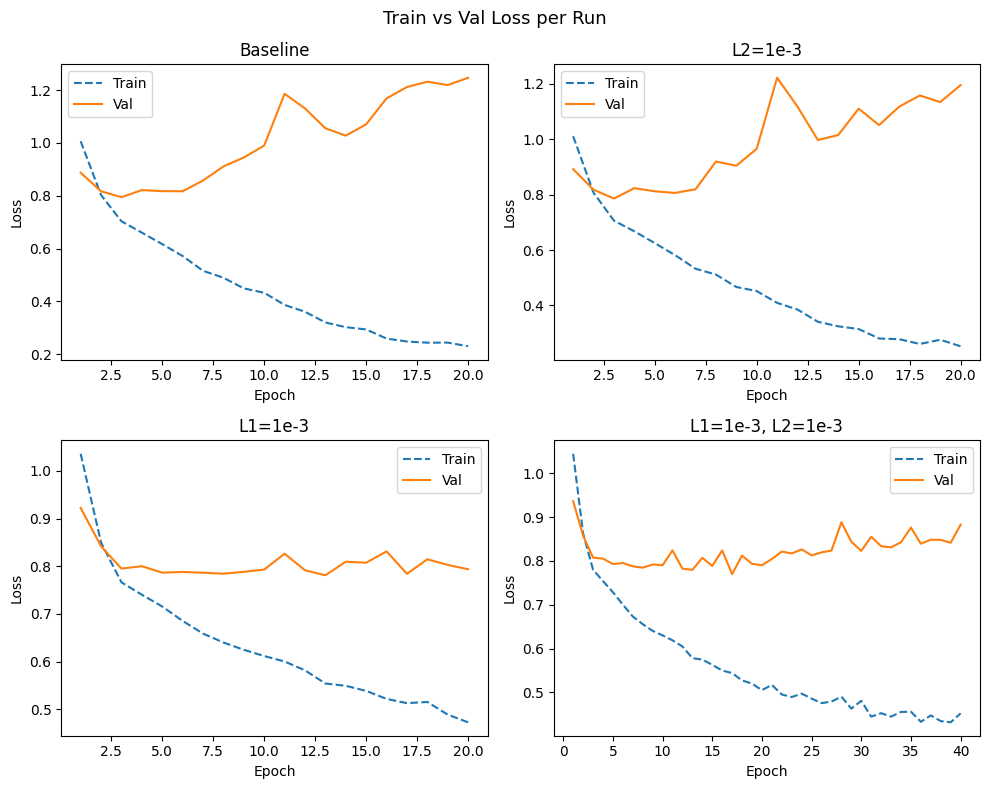

In [13]:
n_runs = len(all_results)
n_cols = 2
n_rows = (n_runs + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows), sharey=False)
axes = axes.flatten()

for ax, (run_label, result) in zip(axes, all_results.items()):
    h = result['history']
    epochs = range(1, len(h['train_loss']) + 1)
    ax.plot(epochs, h['train_loss'], label='Train', linestyle='--')
    ax.plot(epochs, h['val_loss'], label='Val')
    ax.set_title(run_label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

for ax in axes[n_runs:]:
    ax.set_visible(False)

fig.suptitle('Train vs Val Loss per Run', fontsize=13)
plt.tight_layout()
plt.show()

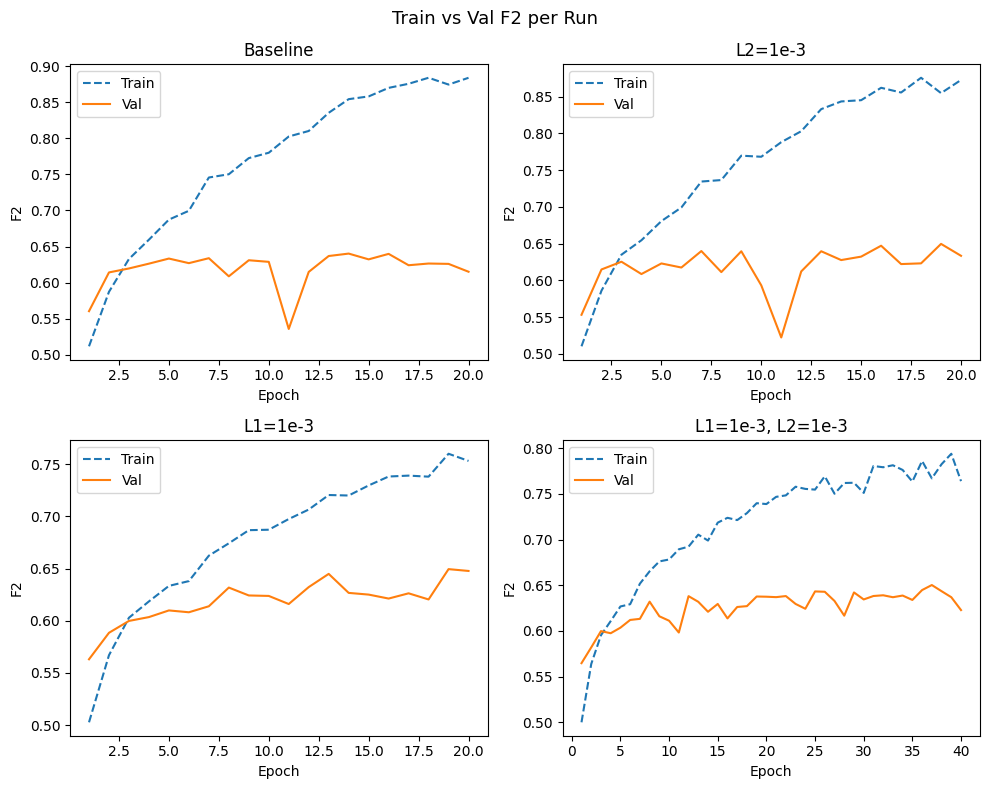

In [14]:
n_runs = len(all_results)
n_cols = 2
n_rows = (n_runs + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows), sharey=False)
axes = axes.flatten()

for ax, (run_label, result) in zip(axes, all_results.items()):
    h = result['history']
    epochs = range(1, len(h['train_f2']) + 1)
    ax.plot(epochs, h['train_f2'], label='Train', linestyle='--')
    ax.plot(epochs, h['val_f2'], label='Val')
    ax.set_title(run_label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F2')
    ax.legend()

for ax in axes[n_runs:]:
    ax.set_visible(False)

fig.suptitle('Train vs Val F2 per Run', fontsize=13)
plt.tight_layout()
plt.show()

## Save & Evaluate Best Run

In [15]:
best_run_label = max(all_results, key=lambda k: all_results[k]['best_val_f2'])
print(f'Best run: {best_run_label} (val F2 = {all_results[best_run_label]["best_val_f2"]:.4f})')

best_model = get_mobilenet_v3_small(num_classes=1, unfreeze_last_n_blocks=3).to(device)
best_model.load_state_dict({k: v.to(device) for k, v in all_results[best_run_label]['best_state'].items()})

torch.save(best_model.state_dict(), 'models/mobilenet_v3_small_partial_unfreeze_penalty_best.pth')
print('Saved to models/mobilenet_v3_small_partial_unfreeze_penalty_best.pth')

Best run: L1=1e-3, L2=1e-3 (val F2 = 0.6502)
Saved to models/mobilenet_v3_small_partial_unfreeze_penalty_best.pth


## Threshold Tuning

In [16]:
best_model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = best_model(images.to(device))
        probs = torch.sigmoid(outputs).squeeze(1)
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.numpy())

thresholds = np.arange(0.01, 0.9, 0.01)
f2_scores = [
    fbeta_score(val_labels, (np.array(val_probs) >= t).astype(int), beta=2, pos_label=1, zero_division=0)
    for t in thresholds
]

best_threshold = thresholds[np.argmax(f2_scores)]
print(f'Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}')

Best threshold: 0.51 | Val F2: 0.6520


## Test Set Evaluation

In [17]:
best_model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = best_model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= best_threshold).long()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(cm)
print()
print(classification_report(all_labels, all_preds, digits=4))

Confusion Matrix:
[[1102  238]
 [  35  136]]

              precision    recall  f1-score   support

           0     0.9692    0.8224    0.8898      1340
           1     0.3636    0.7953    0.4991       171

    accuracy                         0.8193      1511
   macro avg     0.6664    0.8089    0.6944      1511
weighted avg     0.9007    0.8193    0.8456      1511



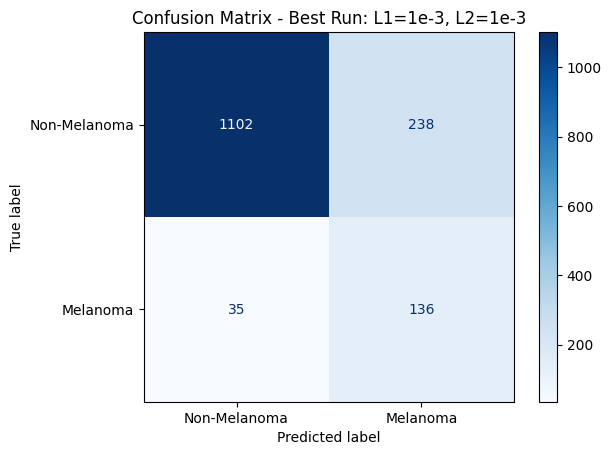

In [18]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - Best Run: {best_run_label}')
plt.show()